In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/fantasticboy123/assign-ml/dataset.csv


/tmp/ipykernel_57/3647215162.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby(['Price_Bin','Discount_Bin'])['Sales_m'].mean().reset_index()


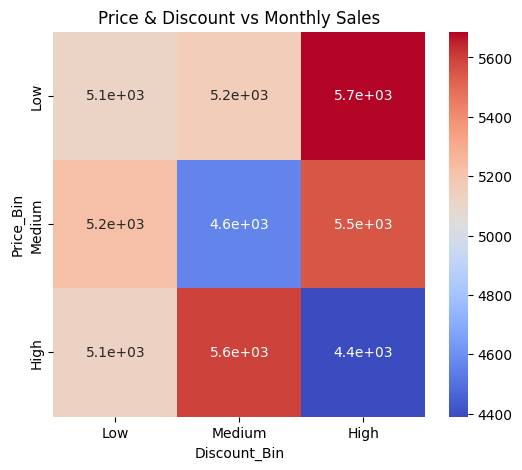

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/fantasticboy123/assign-ml/dataset.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df['Price_Bin'] = pd.qcut(df['Price'], 3, labels=['Low','Medium','High'])
df['Discount_Bin'] = pd.qcut(df['Discount'], 3, labels=['Low','Medium','High'])

# Table
table = df.groupby(['Price_Bin','Discount_Bin'])['Sales_m'].mean().reset_index()
table.to_csv("/kaggle/working/table_RQ2.csv", index=False)

# Pivot for heatmap
pivot = table.pivot(index='Price_Bin', columns='Discount_Bin', values='Sales_m')

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Price & Discount vs Monthly Sales")

# Save figure
plt.savefig("/kaggle/working/figure_RQ2.pdf")
plt.show()